# MalthusJAX Level 2: Selection Operators Demo

This notebook demonstrates the **selection operator architecture** in MalthusJAX:
- `TournamentSelection` — k-tournament selection with configurable tournament size
- `RouletteSelection` — fitness-proportionate selection (Gumbel-Max trick)
- `ElitePoolSelection` — selection from top-k elite individuals

Key concepts covered:
1. Selection operator configuration and instantiation
2. Index-based selection (returns indices, not individuals)
3. Key budgeting and resource management
4. Population slicing and parent selection
5. JAX integration (`jax.jit`, `jax.vmap`)

In [1]:
# Core imports
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

# MalthusJAX imports
from malthusjax.core.genome import (
    RealGenome,
    RealGenomeConfig,
    RealPopulation,
)
from malthusjax.core.fitness import (
    SphereConfig,
    SphereEvaluator,
)
from malthusjax.operators.selection import (
    TournamentSelection,
    RouletteSelection,
    ElitePoolSelection,
)

# Reproducibility
key = jr.PRNGKey(42)
print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.8.0
Devices: [CpuDevice(id=0)]


---
## Setup: Create Population with Fitness

First, let's create a population and evaluate it to have fitness values for selection.

In [2]:
# Create a real-valued population
POP_SIZE = 100
DIMS = 5

genome_config = RealGenomeConfig(shape=(DIMS,), bounds=(-5.0, 5.0))
key, subkey = jr.split(key)
population = RealPopulation.init_random(subkey, genome_config, size=POP_SIZE)

# Evaluate with Sphere function (minimization)
sphere_config = SphereConfig(maximize=False)  # We want to minimize
evaluator = SphereEvaluator(config=sphere_config, data=None)
population = evaluator.evaluate_population(population)

print(f"Population size: {len(population)}")
print(f"Fitness range: [{jnp.min(population.fitness):.4f}, {jnp.max(population.fitness):.4f}]")
print(f"Best fitness (highest, closest to 0): {jnp.max(population.fitness):.4f}")

Population size: 100
Fitness range: [-83.2942, -10.5706]
Best fitness (highest, closest to 0): -10.5706


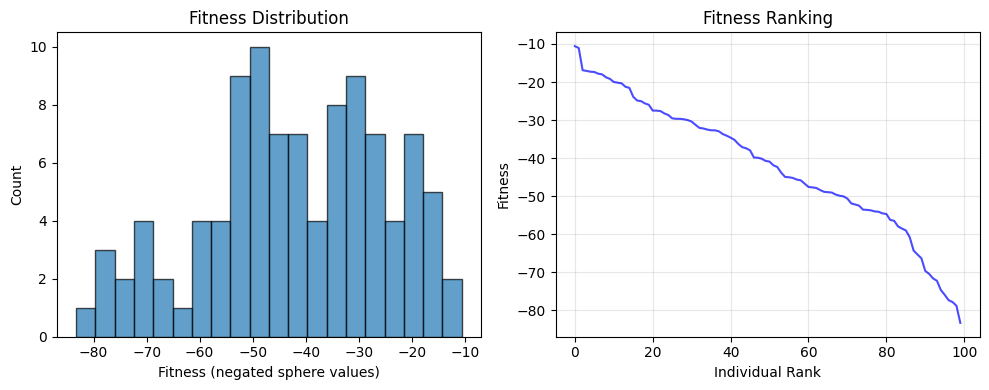

In [3]:
# Visualize fitness distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(np.array(population.fitness), bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Fitness (negated sphere values)')
plt.ylabel('Count')
plt.title('Fitness Distribution')

plt.subplot(1, 2, 2)
sorted_fitness = jnp.sort(population.fitness)[::-1]  # Best to worst
plt.plot(range(len(sorted_fitness)), sorted_fitness, 'b-', alpha=0.7)
plt.xlabel('Individual Rank')
plt.ylabel('Fitness')
plt.title('Fitness Ranking')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 1. Tournament Selection

Tournament selection:
1. Randomly sample `tournament_size` individuals
2. Select the best one from the tournament
3. Repeat for `num_selections`

**Selection pressure**: Higher tournament sizes → stronger selection pressure

In [4]:
# Create tournament selector
N_SELECTIONS = 50

tournament_selector = TournamentSelection(
    num_selections=N_SELECTIONS,
    tournament_size=3
)

print(f"Tournament size: {tournament_selector.tournament_size}")
print(f"Number of selections: {tournament_selector.num_selections}")
print(f"Keys per operation: {tournament_selector.num_keys_per_atomic_operation}")

Tournament size: 3
Number of selections: 50
Keys per operation: 1


In [5]:
# Perform tournament selection
key, subkey = jr.split(key)
selected_indices = tournament_selector(subkey, population)

print(f"Selected indices shape: {selected_indices.shape}")
print(f"Selected indices (first 10): {selected_indices[:10]}")
print(f"Unique selections: {len(jnp.unique(selected_indices))}/{N_SELECTIONS}")

# Check fitness of selected individuals
selected_fitness = population.fitness[selected_indices]
print(f"\nSelected fitness range: [{jnp.min(selected_fitness):.4f}, {jnp.max(selected_fitness):.4f}]")
print(f"Mean selected fitness: {jnp.mean(selected_fitness):.4f}")
print(f"Population mean fitness: {jnp.mean(population.fitness):.4f}")

Selected indices shape: (50,)
Selected indices (first 10): [37 18 76 85 28 48 41 72 41 38]
Unique selections: 32/50

Selected fitness range: [-48.3816, -10.5706]
Mean selected fitness: -25.4073
Population mean fitness: -41.9623


In [6]:
# Compare different tournament sizes
tournament_sizes = [2, 3, 5, 8]
key_base = jr.PRNGKey(123)

results = {}
for t_size in tournament_sizes:
    selector = TournamentSelection(num_selections=N_SELECTIONS, tournament_size=t_size)
    key_base, subkey = jr.split(key_base)
    indices = selector(subkey, population)
    selected_fitness = population.fitness[indices]
    
    results[t_size] = {
        'mean_fitness': float(jnp.mean(selected_fitness)),
        'std_fitness': float(jnp.std(selected_fitness)),
        'unique_count': int(len(jnp.unique(indices))),
    }

# Display results
print("Tournament Size Comparison:")
print(f"{'Size':<6} {'Mean Fitness':<12} {'Std Dev':<10} {'Unique':<8}")
print("-" * 40)
for t_size, stats in results.items():
    print(f"{t_size:<6} {stats['mean_fitness']:<12.4f} {stats['std_fitness']:<10.4f} {stats['unique_count']:<8}")

Tournament Size Comparison:
Size   Mean Fitness Std Dev    Unique  
----------------------------------------
2      -31.4386     12.5007    36      
3      -26.6712     8.5291     32      
5      -25.0360     8.7235     37      
8      -20.2795     6.7331     25      


---
## 2. Roulette Wheel Selection

Roulette (fitness-proportionate) selection:
- Probability of selection proportional to fitness
- Uses **Gumbel-Max trick** for efficient parallel sampling
- `temperature` controls selection pressure (lower = more selective)

In [7]:
# Create roulette selector
roulette_selector = RouletteSelection(
    num_selections=N_SELECTIONS,
    temperature=1.0,  # Standard temperature
    use_gumbel_trick=True
)

print(f"Temperature: {roulette_selector.temperature}")
print(f"Use Gumbel trick: {roulette_selector.use_gumbel_trick}")

Temperature: 1.0
Use Gumbel trick: True


In [8]:
# Perform roulette selection
key, subkey = jr.split(key)
roulette_indices = roulette_selector(subkey, population)

roulette_fitness = population.fitness[roulette_indices]
print(f"Roulette selected fitness range: [{jnp.min(roulette_fitness):.4f}, {jnp.max(roulette_fitness):.4f}]")
print(f"Mean selected fitness: {jnp.mean(roulette_fitness):.4f}")
print(f"Unique selections: {len(jnp.unique(roulette_indices))}/{N_SELECTIONS}")

Roulette selected fitness range: [-18.7549, -10.5706]
Mean selected fitness: -10.9605
Unique selections: 3/50


In [9]:
# Compare different temperatures
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
key_base = jr.PRNGKey(456)

temp_results = {}
for temp in temperatures:
    selector = RouletteSelection(num_selections=N_SELECTIONS, temperature=temp)
    key_base, subkey = jr.split(key_base)
    indices = selector(subkey, population)
    selected_fitness = population.fitness[indices]
    
    temp_results[temp] = {
        'mean_fitness': float(jnp.mean(selected_fitness)),
        'std_fitness': float(jnp.std(selected_fitness)),
        'unique_count': int(len(jnp.unique(indices))),
    }

print("Temperature Comparison (Roulette):")
print(f"{'Temp':<6} {'Mean Fitness':<12} {'Std Dev':<10} {'Unique':<8}")
print("-" * 40)
for temp, stats in temp_results.items():
    print(f"{temp:<6} {stats['mean_fitness']:<12.4f} {stats['std_fitness']:<10.4f} {stats['unique_count']:<8}")

Temperature Comparison (Roulette):
Temp   Mean Fitness Std Dev    Unique  
----------------------------------------
0.1    -10.5706     0.0000     1       
0.5    -10.6984     0.2157     2       
1.0    -10.7673     0.2409     2       
2.0    -11.1916     1.6583     5       
5.0    -17.4059     6.1865     16      


---
## 3. Elite Pool Selection

Elite pool selection:
1. Find the top-k individuals using `jax.lax.top_k`
2. Randomly sample from this elite pool
3. Very **high selection pressure** (only best individuals can be parents)

In [10]:
# Create elite pool selector
elite_selector = ElitePoolSelection(
    num_selections=N_SELECTIONS,
    elite_k=10  # Top 10 individuals
)

print(f"Elite pool size (k): {elite_selector.elite_k}")
print(f"Selections from pool: {elite_selector.num_selections}")

Elite pool size (k): 10
Selections from pool: 50


In [11]:
# Perform elite selection
key, subkey = jr.split(key)
elite_indices = elite_selector(subkey, population)

elite_fitness = population.fitness[elite_indices]
print(f"Elite selected fitness range: [{jnp.min(elite_fitness):.4f}, {jnp.max(elite_fitness):.4f}]")
print(f"Mean selected fitness: {jnp.mean(elite_fitness):.4f}")
print(f"Unique selections: {len(jnp.unique(elite_indices))}/{N_SELECTIONS}")

# Show the actual elite pool
_, top_k_indices = jax.lax.top_k(population.fitness, elite_selector.elite_k)
print(f"\nElite pool indices: {top_k_indices}")
print(f"Elite pool fitness: {population.fitness[top_k_indices]}")

Elite selected fitness range: [-19.1645, -10.5706]
Mean selected fitness: -16.8224
Unique selections: 10/50

Elite pool indices: [95 96 85 76 61 26 33 12 25 41]
Elite pool fitness: [-10.570564 -11.062389 -16.889975 -17.07945  -17.280346 -17.355556
 -17.80189  -17.979424 -18.754856 -19.164528]


In [12]:
# Compare different elite pool sizes
elite_ks = [5, 10, 20, 30]
key_base = jr.PRNGKey(789)

elite_results = {}
for k in elite_ks:
    selector = ElitePoolSelection(num_selections=N_SELECTIONS, elite_k=k)
    key_base, subkey = jr.split(key_base)
    indices = selector(subkey, population)
    selected_fitness = population.fitness[indices]
    
    elite_results[k] = {
        'mean_fitness': float(jnp.mean(selected_fitness)),
        'std_fitness': float(jnp.std(selected_fitness)),
        'unique_count': int(len(jnp.unique(indices))),
    }

print("Elite Pool Size Comparison:")
print(f"{'Elite K':<8} {'Mean Fitness':<12} {'Std Dev':<10} {'Unique':<8}")
print("-" * 42)
for k, stats in elite_results.items():
    print(f"{k:<8} {stats['mean_fitness']:<12.4f} {stats['std_fitness']:<10.4f} {stats['unique_count']:<8}")

Elite Pool Size Comparison:
Elite K  Mean Fitness Std Dev    Unique  
------------------------------------------
5        -14.2970     3.1119     5       
10       -15.9192     2.9982     10      
20       -19.6432     4.2542     18      
30       -20.1778     5.5686     23      


---
## 4. Selection Pressure Comparison

Let's compare all three selection methods on the same population.

In [13]:
# Compare all selection methods
key_base = jr.PRNGKey(999)

selectors = {
    'Tournament (k=3)': TournamentSelection(num_selections=N_SELECTIONS, tournament_size=3),
    'Roulette (T=1.0)': RouletteSelection(num_selections=N_SELECTIONS, temperature=0.0),
    'Elite Pool (k=10)': ElitePoolSelection(num_selections=N_SELECTIONS, elite_k=10),
}

comparison_results = {}
for name, selector in selectors.items():
    key_base, subkey = jr.split(key_base)
    indices = selector(subkey, population)
    selected_fitness = population.fitness[indices]
    
    comparison_results[name] = {
        'indices': indices,
        'fitness': selected_fitness,
        'mean': float(jnp.mean(selected_fitness)),
        'std': float(jnp.std(selected_fitness)),
        'unique': int(len(jnp.unique(indices))),
    }

print("Selection Method Comparison:")
print(f"{'Method':<18} {'Mean Fitness':<12} {'Std Dev':<10} {'Unique':<8}")
print("-" * 52)
for name, stats in comparison_results.items():
    print(f"{name:<18} {stats['mean']:<12.4f} {stats['std']:<10.4f} {stats['unique']:<8}")

print(f"\nPopulation mean: {jnp.mean(population.fitness):.4f}")
print(f"Population std:  {jnp.std(population.fitness):.4f}")

Selection Method Comparison:
Method             Mean Fitness Std Dev    Unique  
----------------------------------------------------
Tournament (k=3)   -28.3767     10.2641    34      
Roulette (T=1.0)   -47.6846     0.0000     1       
Elite Pool (k=10)  -16.4118     2.8574     10      

Population mean: -41.9623
Population std:  17.1931


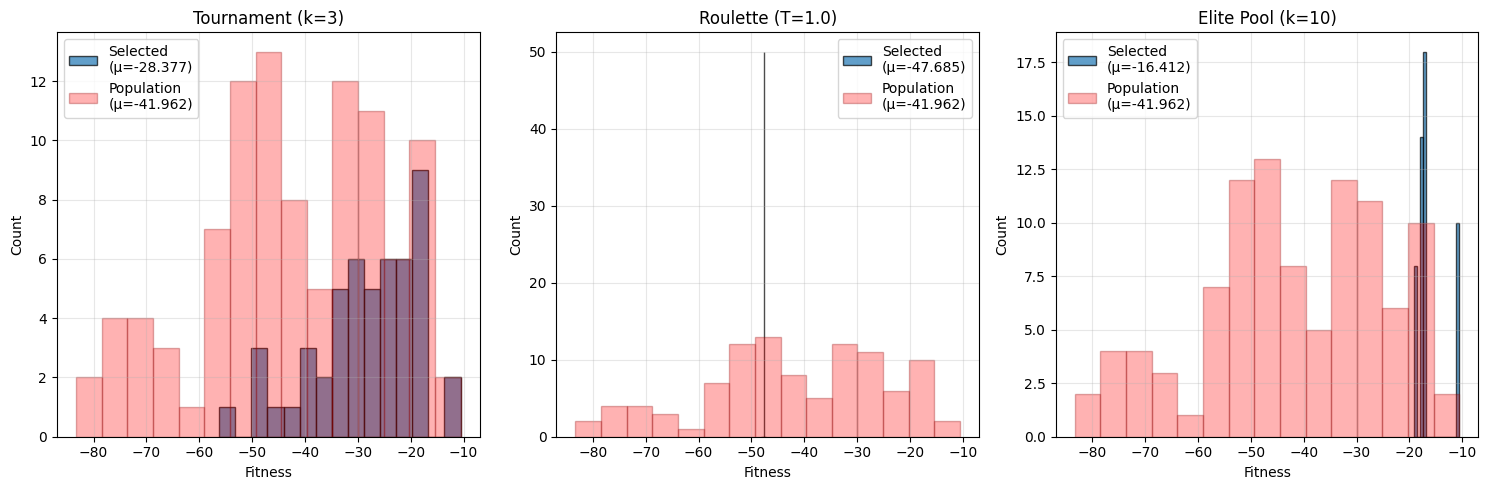

In [14]:
# Visualize selection distributions
plt.figure(figsize=(15, 5))

for i, (name, stats) in enumerate(comparison_results.items(), 1):
    plt.subplot(1, 3, i)
    
    # Histogram of selected fitness
    plt.hist(np.array(stats['fitness']), bins=15, alpha=0.7, 
             label=f'Selected\n(μ={stats["mean"]:.3f})', edgecolor='black')
    
    # Population distribution for reference
    plt.hist(np.array(population.fitness), bins=15, alpha=0.3, 
             label=f'Population\n(μ={jnp.mean(population.fitness):.3f})', 
             color='red', edgecolor='darkred')
    
    plt.title(name)
    plt.xlabel('Fitness')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Selection Frequency Analysis

How often does each individual get selected?

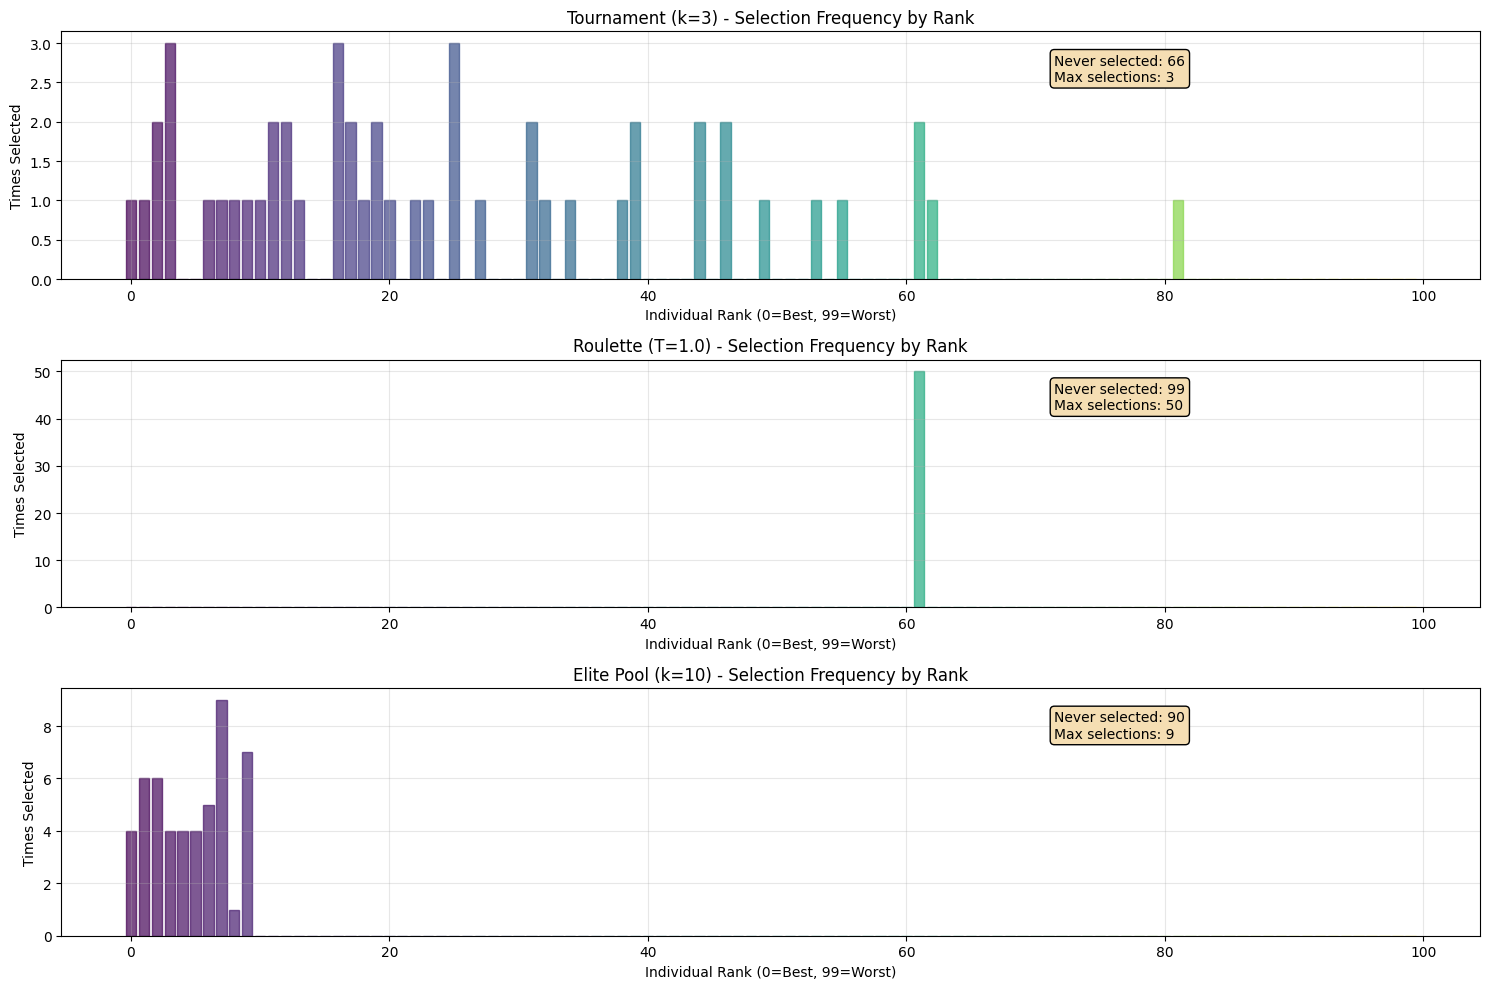

In [15]:
# Analyze selection frequency
def analyze_selection_frequency(indices, pop_size):
    """Count how many times each individual was selected."""
    counts = jnp.bincount(indices, length=pop_size)
    return counts

plt.figure(figsize=(15, 10))

# Sort population by fitness for better visualization
fitness_order = jnp.argsort(population.fitness)[::-1]  # Best to worst
sorted_fitness = population.fitness[fitness_order]

for i, (name, stats) in enumerate(comparison_results.items(), 1):
    freq_counts = analyze_selection_frequency(stats['indices'], POP_SIZE)
    sorted_counts = freq_counts[fitness_order]
    
    plt.subplot(3, 1, i)
    
    # Bar plot: selection frequency vs individual rank
    bars = plt.bar(range(POP_SIZE), sorted_counts, alpha=0.7)
    
    # Color bars by fitness
    colors = plt.cm.viridis(np.linspace(0, 1, POP_SIZE))
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    plt.title(f'{name} - Selection Frequency by Rank')
    plt.xlabel('Individual Rank (0=Best, 99=Worst)')
    plt.ylabel('Times Selected')
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    never_selected = jnp.sum(freq_counts == 0)
    plt.text(0.7, 0.8, f'Never selected: {never_selected}\nMax selections: {jnp.max(freq_counts)}', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

---
## 6. Parent Selection for Breeding

Practical example: Select parents and create parent pairs for crossover.

In [16]:
# Select parents for breeding
N_PAIRS = 25  # Number of parent pairs

tournament_selector = TournamentSelection(
    num_selections=N_PAIRS * 2,  # Need 2 parents per pair
    tournament_size=3
)

key, subkey = jr.split(key)
parent_indices = tournament_selector(subkey, population)

# Reshape into parent pairs
parent_pairs = parent_indices.reshape(N_PAIRS, 2)

print(f"Selected {N_PAIRS} parent pairs:")
print(f"Parent indices shape: {parent_pairs.shape}")
print(f"First 5 pairs: {parent_pairs[:5]}")

# Get parent genomes
parent1_pop = population[parent_pairs[:, 0]]
parent2_pop = population[parent_pairs[:, 1]]

print(f"\nParent 1 fitness (first 5): {parent1_pop.fitness[:5]}")
print(f"Parent 2 fitness (first 5): {parent2_pop.fitness[:5]}")

Selected 25 parent pairs:
Parent indices shape: (25, 2)
First 5 pairs: [[16  9]
 [ 7 12]
 [12 85]
 [41 17]
 [40  7]]

Parent 1 fitness (first 5): [-50.63566  -21.237005 -17.979424 -19.164528 -25.615883]
Parent 2 fitness (first 5): [-29.664059 -17.979424 -16.889975 -21.527102 -21.237005]


In [17]:
# Analyze parent pair quality
parent1_fitness = population.fitness[parent_pairs[:, 0]]
parent2_fitness = population.fitness[parent_pairs[:, 1]]

pair_fitness_sum = parent1_fitness + parent2_fitness
pair_fitness_max = jnp.maximum(parent1_fitness, parent2_fitness)
pair_fitness_min = jnp.minimum(parent1_fitness, parent2_fitness)

print(f"Parent pair analysis:")
print(f"  Mean combined fitness: {jnp.mean(pair_fitness_sum):.4f}")
print(f"  Mean best parent: {jnp.mean(pair_fitness_max):.4f}")
print(f"  Mean worst parent: {jnp.mean(pair_fitness_min):.4f}")
print(f"  Population mean: {jnp.mean(population.fitness):.4f}")

# Check for identical parent pairs (should be rare)
identical_pairs = jnp.sum(parent_pairs[:, 0] == parent_pairs[:, 1])
print(f"  Identical parent pairs: {identical_pairs}/{N_PAIRS}")

Parent pair analysis:
  Mean combined fitness: -55.1188
  Mean best parent: -23.1568
  Mean worst parent: -31.9621
  Population mean: -41.9623
  Identical parent pairs: 0/25


---
## 7. JIT Compilation and Performance

Selection operators are JAX PyTrees and fully compatible with `jax.jit`.

In [18]:
# JIT compile selection operators
tournament_jit = jax.jit(tournament_selector)
roulette_jit = jax.jit(roulette_selector)
elite_jit = jax.jit(elite_selector)

# Warm-up (compilation)
test_key = jr.PRNGKey(0)
_ = tournament_jit(test_key, population.fitness)  # Can pass fitness directly
_ = roulette_jit(test_key, population.fitness)
_ = elite_jit(test_key, population.fitness)

print("JIT compilation completed!")

JIT compilation completed!


In [19]:
# Benchmark performance
import time

N_ITERATIONS = 1000
fitness_array = population.fitness

def benchmark_selector(selector, selector_jit, name):
    key_bench = jr.PRNGKey(42)
    
    # Non-JIT
    start = time.perf_counter()
    for _ in range(N_ITERATIONS):
        key_bench, subkey = jr.split(key_bench)
        _ = selector(subkey, fitness_array)
    non_jit_time = time.perf_counter() - start
    
    # JIT
    key_bench = jr.PRNGKey(42)
    start = time.perf_counter()
    for _ in range(N_ITERATIONS):
        key_bench, subkey = jr.split(key_bench)
        _ = selector_jit(subkey, fitness_array)
    jit_time = time.perf_counter() - start
    
    speedup = non_jit_time / jit_time
    print(f"{name:12}: Non-JIT {non_jit_time*1000:6.2f}ms | JIT {jit_time*1000:6.2f}ms | Speedup {speedup:.1f}x")
    return non_jit_time, jit_time, speedup

print(f"Benchmarking {N_ITERATIONS} selections (population size {POP_SIZE}):")
benchmark_selector(tournament_selector, tournament_jit, "Tournament")
benchmark_selector(roulette_selector, roulette_jit, "Roulette")
benchmark_selector(elite_selector, elite_jit, "Elite Pool")

Benchmarking 1000 selections (population size 100):
Tournament  : Non-JIT 182.82ms | JIT  71.61ms | Speedup 2.6x
Roulette    : Non-JIT 251.18ms | JIT  62.42ms | Speedup 4.0x
Elite Pool  : Non-JIT 232.93ms | JIT  62.11ms | Speedup 3.8x


(0.2329347919439897, 0.06210920796729624, 3.7504067362546643)

---
## 8. Custom Selection Operator

Example of implementing a custom selection operator following the MalthusJAX pattern.

In [20]:
from flax import struct
from malthusjax.operators.base import BaseSelection
from typing import Any, Optional
import chex

@struct.dataclass
class RankSelection(BaseSelection):
    """Rank-based selection: probability based on rank, not raw fitness.
    
    More robust to fitness scaling issues than roulette selection.
    """
    
    selection_pressure: float = struct.field(pytree_node=False, default=2.0)
    
    @property
    def num_keys_per_atomic_operation(self) -> int:
        return 1
    
    def _select(self, keys: chex.Array, fitness: chex.Array, config: Optional[Any] = None, **kwargs: Any) -> chex.Array:
        rng = keys[0] if keys.ndim > 1 else keys
        pop_size = fitness.shape[0]
        
        # 1. Rank individuals (best = 0, worst = pop_size-1)
        ranks = jnp.argsort(jnp.argsort(-fitness))  # Descending fitness order
        
        # 2. Linear ranking probability
        # P(rank) = (2 - selection_pressure) / N + 2 * rank * (selection_pressure - 1) / (N * (N - 1))
        s = self.selection_pressure
        N = pop_size
        
        # Invert ranks so best gets highest probability
        inverted_ranks = N - 1 - ranks
        
        prob_base = (2 - s) / N
        prob_slope = 2 * (s - 1) / (N * (N - 1))
        probabilities = prob_base + prob_slope * inverted_ranks
        
        # 3. Sample according to probabilities
        return jax.random.choice(
            rng, a=pop_size, shape=(self.num_selections,), p=probabilities, replace=True
        )

In [21]:
# Test custom rank selection
rank_selector = RankSelection(
    num_selections=N_SELECTIONS,
    selection_pressure=1.5  # Moderate selection pressure
)

key, subkey = jr.split(key)
rank_indices = rank_selector(subkey, population)
rank_fitness = population.fitness[rank_indices]

print(f"Rank Selection Results:")
print(f"  Mean fitness: {jnp.mean(rank_fitness):.4f}")
print(f"  Std fitness: {jnp.std(rank_fitness):.4f}")
print(f"  Unique selections: {len(jnp.unique(rank_indices))}/{N_SELECTIONS}")
print(f"  Population mean: {jnp.mean(population.fitness):.4f}")

Rank Selection Results:
  Mean fitness: -36.7495
  Std fitness: 13.8790
  Unique selections: 40/50
  Population mean: -41.9623


In [22]:
# Compare rank selection with different selection pressures
pressures = [1.1, 1.5, 2.0, 2.5]
key_base = jr.PRNGKey(111)

print("Rank Selection Pressure Comparison:")
print(f"{'Pressure':<10} {'Mean Fitness':<12} {'Std Dev':<10}")
print("-" * 35)

for pressure in pressures:
    selector = RankSelection(num_selections=N_SELECTIONS, selection_pressure=pressure)
    key_base, subkey = jr.split(key_base)
    indices = selector(subkey, population)
    selected_fitness = population.fitness[indices]
    
    print(f"{pressure:<10} {jnp.mean(selected_fitness):<12.4f} {jnp.std(selected_fitness):<10.4f}")

Rank Selection Pressure Comparison:
Pressure   Mean Fitness Std Dev   
-----------------------------------
1.1        -37.8878     16.9933   
1.5        -34.0629     15.8156   
2.0        -31.9955     12.1008   
2.5        -29.4246     12.1795   


---
## Summary

| Operator | Key Parameters | Selection Pressure | Best For |
|----------|---------------|-------------------|----------|
| `TournamentSelection` | `tournament_size` | Medium to High | General purpose, tunable |
| `RouletteSelection` | `temperature` | Low to Medium | Fitness-proportionate, smooth |
| `ElitePoolSelection` | `elite_k` | Very High | Exploitation, fast convergence |
| `RankSelection` (custom) | `selection_pressure` | Tunable | Robust to fitness scaling |

**Key insights**:
- **Tournament**: Most widely used, good balance of exploration/exploitation
- **Roulette**: Sensitive to fitness scaling, works best with normalized fitness
- **Elite Pool**: Very strong selection pressure, risk of premature convergence
- **Rank-based**: Robust alternative to roulette, independent of fitness magnitude

All operators:
- Return **indices** (not genomes) for memory efficiency
- Support both population objects and raw fitness arrays
- Are JAX-compatible PyTrees (`jax.jit`, `jax.vmap`)
- Follow the `BaseSelection` interface